In [1]:
import os
os.getcwd()

'd:\\Programming\\labwork\\123cs0061\\cv_labexam'

### Question 3

In [10]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn

LR = 1e-3
EPOCHS = 30
BATCH_SIZE = 32
NUM_WORKERS = 2
NUM_CLASSES = 10
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
import numpy as np
import os
from PIL import Image

def load_image(img_path):
    img = Image.open(img_path).convert('RGB')

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1), 
        transforms.Resize((28, 28)), 
        transforms.ToTensor()
    ])
    
    img_tensor = transform(img)
    return img_tensor

def load_images():
    train_data = []
    images = ["bright.png", "kid.png", "tiger.png"]
    
    for img_name in images:
        img_path = os.path.join(os.getcwd(), "data", "exam", img_name)
        if os.path.exists(img_path):
            img_tensor = load_image(img_path)
            train_data.append(img_tensor)
        else:
            print(f"Warning: File not found -> {img_path}")
    if train_data:
        train_data = torch.stack(train_data)
    else:
        train_data = torch.empty(0)
        
    return train_data

In [30]:
train_data = load_images()
print(train_data.shape)

torch.Size([3, 1, 28, 28])


In [31]:
class DenoisingImages(Dataset):
    def __init__(self, data, noise_factor=0.1):
        # Safely handle data whether it's passed as a Tensor or Numpy array
        if isinstance(data, torch.Tensor):
            self.data = data.clone().detach()
        else:
            self.data = torch.tensor(data, dtype=torch.float32)
            
        self.noise_factor = noise_factor
    
    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        clean = self.data[index]
        noise = self.noise_factor * torch.randn_like(clean)
        
        noisy = torch.clamp(clean + noise, 0.0, 1.0) 
        
        return noisy, clean

In [33]:
traindataset = DenoisingImages(data=train_data)

In [44]:
trainloader = DataLoader(
    dataset=traindataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

In [37]:
import torch.nn as nn

class ConvDAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.bottleneck = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid() 
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.bottleneck(x)
        x = self.decoder(x)
        return x

In [41]:
from torchinfo import summary
model = ConvDAE()
model = model.to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.L1Loss()
summary(model, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
ConvDAE                                  [1, 1, 28, 28]            --
├─Sequential: 1-1                        [1, 16, 7, 7]             --
│    └─Conv2d: 2-1                       [1, 32, 28, 28]           320
│    └─ReLU: 2-2                         [1, 32, 28, 28]           --
│    └─MaxPool2d: 2-3                    [1, 32, 14, 14]           --
│    └─Conv2d: 2-4                       [1, 16, 14, 14]           4,624
│    └─ReLU: 2-5                         [1, 16, 14, 14]           --
│    └─MaxPool2d: 2-6                    [1, 16, 7, 7]             --
├─Sequential: 1-2                        [1, 16, 7, 7]             --
│    └─Conv2d: 2-7                       [1, 16, 7, 7]             2,320
│    └─ReLU: 2-8                         [1, 16, 7, 7]             --
├─Sequential: 1-3                        [1, 1, 28, 28]            --
│    └─Upsample: 2-9                     [1, 16, 14, 14]           --
│    └─C

In [42]:
import torch

def psnr(pred, target):
    mse = torch.mean((pred - target) ** 2)
    return 20 * torch.log10(1.0 / torch.sqrt(mse))

In [64]:
train_losses = []
for epoch in range(1):
    running_loss = 0.0
    model.train()
    for noisy, clean in trainloader:
        noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(noisy)
        loss = criterion(outputs, clean)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_loss = running_loss / len(trainloader)
    train_losses.append(epoch_loss)
    
    print(f"Epoch [{epoch + 1}] Train Loss: {epoch_loss:.4f}")

Epoch [1] Train Loss: 0.2723


In [ ]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    noisy, clean = next(iter(trainloader))
    noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)

    recon = model(noisy)

noisy = noisy.to("cpu")
clean = clean.to("cpu")
recon = recon.to("cpu")
recon = recon.view(recon.size(0), 3, 32, 32)

fig, axes = plt.subplots(nrows = 3, ncols = 6, figsize=(10, 5))
for i in range(6):
    axes[0, i].imshow(clean[i].permute(1, 2, 0))
    axes[0, i].set_title("Clean")

    axes[1, i].imshow(noisy[i].permute(1, 2, 0))
    axes[1, i].set_title("Noisy")

    axes[2, i].imshow(recon[i].permute(1, 2, 0))
    axes[2, i].set_title("Reconstructed")

    for ax in axes[:, i]:
        ax.axis("off")
plt.show()

### Question 5

In [46]:
import numpy as np
import cv2

img_dir = os.path.join(os.getcwd(), "data", "exam", "kid.png")
img = cv2.imread(img_dir) / 255.0
mean = 0
std = 0.1
noise = np.random.normal(mean, std, img.shape)
noisy_image = img + noise
noisy_image = np.clip(noisy_image, 0, 1)

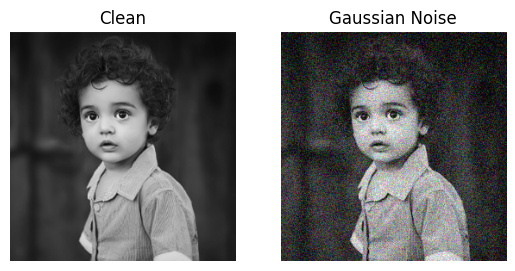

In [47]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=1, ncols=2)
axes[0].imshow(img)
axes[0].set_title("Clean")
axes[0].axis("off")
axes[1].imshow(noisy_image)
axes[1].set_title("Gaussian Noise")
axes[1].axis("off")

plt.show()

In [48]:
def arithmetic_mean_filter(image, kernel=3):
    pad = kernel // 2
    padded = np.pad(img, pad, mode='reflect')
    output = np.zeros_like(img, dtype=np.float32)
    H, W, C = image.shape
    for i in range(H):
        for j in range(W):
            region = padded[i:i + kernel, j:j + kernel]
            output[i, j] = np.mean(region)
    return output

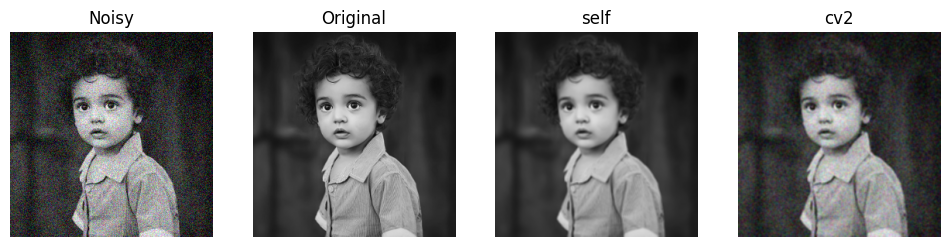

In [49]:
recon = arithmetic_mean_filter(noisy_image)
recon_cv = cv2.blur(noisy_image, (3, 3))

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 5))
axes[0].imshow(noisy_image)
axes[0].set_title("Noisy")
axes[0].axis("off")
axes[1].imshow(img)
axes[1].set_title("Original")
axes[1].axis("off")
axes[2].imshow(recon)
axes[2].set_title("self")
axes[2].axis("off")
axes[3].imshow(recon_cv)
axes[3].set_title("cv2")
axes[3].axis("off")
plt.show()

In [50]:
def geometric_mean_filter(image, kernel=3):
    pad = kernel // 2
    padded = np.pad(img, pad, mode='reflect')
    output = np.zeros_like(img, dtype=np.float32)
    H, W, C = image.shape
    for i in range(H):
        for j in range(W):
            region = padded[i:i + kernel, j:j + kernel]
            
            region = np.where(region == 0, 1e-6, region)
            log_region = np.log(region)
            mean_log = np.mean(log_region)
            output[i, j] = np.exp(mean_log)
    return output

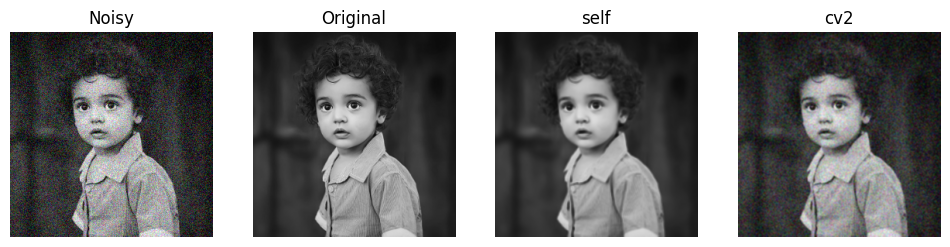

In [51]:
recon = geometric_mean_filter(noisy_image)
recon_cv = cv2.GaussianBlur(noisy_image, (3, 3), 0)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 5))
axes[0].imshow(noisy_image)
axes[0].set_title("Noisy")
axes[0].axis("off")
axes[1].imshow(img)
axes[1].set_title("Original")
axes[1].axis("off")
axes[2].imshow(recon)
axes[2].set_title("self")
axes[2].axis("off")
axes[3].imshow(recon_cv)
axes[3].set_title("cv2")
axes[3].axis("off")
plt.show()

In [52]:
def add_salt_pepper_noise(image, prob=0.05, salt=True, pepper=True):
    noisy = image.copy()
    if salt:
        salt_mask = np.random.rand(*image.shape) < (prob/2)
        noisy[salt_mask] = 255

    if pepper: 
        pepper_mask = np.random.rand(*image.shape) < (prob/2)
        noisy[pepper_mask] = 0
    return noisy

In [53]:
def median_filter(image, kernel):
    pad = kernel // 2
    padded = np.pad(image, pad, mode='reflect')
    output = np.zeros_like(image)

    H, W, C = image.shape
    for i in range(H):
        for j in range(W):
            region = padded[i:i+kernel, j:j+kernel]
            output[i, j] = np.median(region)
    
    return output

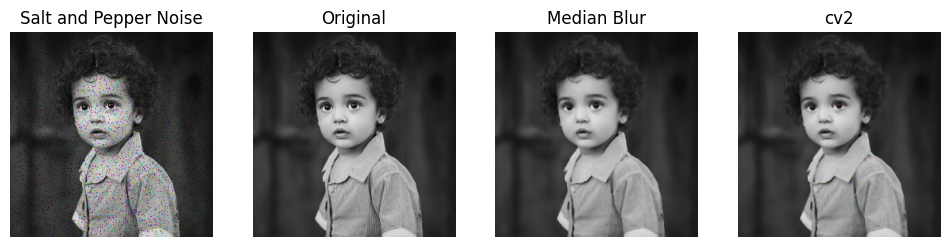

In [54]:
noisy_image = add_salt_pepper_noise(img)
recon = median_filter(noisy_image, 3)
noisy_image = (noisy_image * 255).astype('uint8')
recon_cv = cv2.medianBlur(noisy_image, 3)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 5))
axes[0].imshow(noisy_image)
axes[0].set_title("Salt and Pepper Noise")
axes[0].axis("off")
axes[1].imshow(img)
axes[1].set_title("Original")
axes[1].axis("off")
axes[2].imshow(recon)
axes[2].set_title("Median Blur")
axes[2].axis("off")
axes[3].imshow(recon_cv)
axes[3].set_title("cv2")
axes[3].axis("off")
plt.show()

In [55]:
def max_filter(image, kernel):
    pad = kernel // 2
    padded = np.pad(image, pad, mode='reflect')
    output = np.zeros_like(image)

    H, W, C = image.shape
    for i in range(H):
        for j in range(W):
            region = padded[i:i+kernel, j:j+kernel]
            output[i, j] = np.max(region)
    
    return output

def min_filter(image, kernel):
    pad = kernel // 2
    padded = np.pad(image, pad, mode='reflect')
    output = np.zeros_like(image)

    H, W, C = image.shape
    for i in range(H):
        for j in range(W):
            region = padded[i:i+kernel, j:j+kernel]
            output[i, j] = np.min(region)
    
    return output

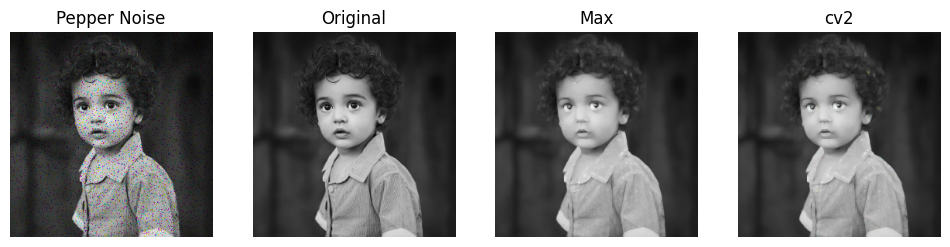

In [56]:
noisy_image = add_salt_pepper_noise(img, prob=0.1, salt=False)
recon = max_filter(noisy_image, 3)
# noisy_image = (noisy_image * 255).astype('uint8')
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
recon_cv = cv2.dilate(noisy_image, kernel)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 5))
axes[0].imshow(noisy_image)
axes[0].set_title("Pepper Noise")
axes[0].axis("off")
axes[1].imshow(img)
axes[1].set_title("Original")
axes[1].axis("off")
axes[2].imshow(recon)
axes[2].set_title("Max")
axes[2].axis("off")
axes[3].imshow(recon_cv)
axes[3].set_title("cv2")
axes[3].axis("off")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.023529411764705882..255.0].


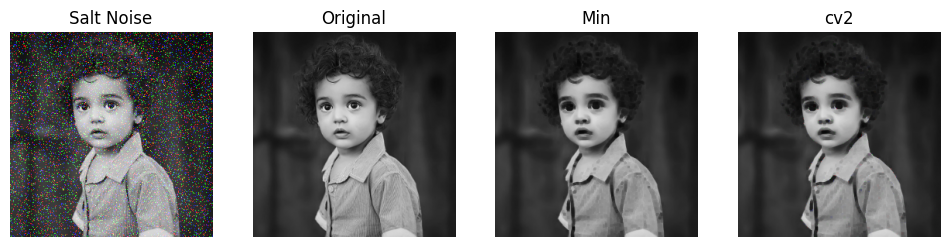

In [57]:
noisy_image = add_salt_pepper_noise(img, prob=0.1, pepper=False)
recon = min_filter(noisy_image, 3)
# noisy_image = (noisy_image * 255).astype('uint8')
kernel = np.ones((3, 3), np.uint8)
recon_cv = cv2.erode(noisy_image, kernel, iterations=1)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 5))
axes[0].imshow(noisy_image)
axes[0].set_title("Salt Noise")
axes[0].axis("off")
axes[1].imshow(img)
axes[1].set_title("Original")
axes[1].axis("off")
axes[2].imshow(recon)
axes[2].set_title("Min")
axes[2].axis("off")
axes[3].imshow(recon_cv)
axes[3].set_title("cv2")
axes[3].axis("off")
plt.show()

In [58]:
def adaptive_gaussian_noise(img, k=0.5, win=5):
    if img.max() <= 1.0:
        img = img * 255
    img = img.astype(np.float32)
    mean = cv2.blur(img, (win, win))
    sq_mean = cv2.blur(img**2, (win, win))
    var = sq_mean - mean**2
    # sigma = 25 + k * np.sqrt(var)
    sigma = 40
    noise = np.random.normal(0, sigma, img.shape)
    noisy = img + noise
    # print(noisy)

    return np.clip(noisy, 0, 255).astype(np.uint8)

In [59]:
def adaptive_filter(img, k, noise_var):
    pad = k // 2
    padded = np.pad(img, pad, mode='reflect')
    out = np.zeros_like(img, dtype=np.float32)
    H, W, C = img.shape
    for i in range(H):
        for j in range(W):
            region = padded[i:i+k, j:j+k]
            for c in range(C):
                local_mean = np.mean(region[:, :, c])
                local_var = np.var(region[:, :, c])
                ratio = noise_var / (local_var + 1e-6)
                ratio = min(ratio, 0.8)
                if local_var == 0:
                    out[i, j, c] = local_mean
                else:
                    out[i, j, c] = img[i, j, c] - (ratio) * (img[i, j, c] - local_mean)
    return np.clip(out, 0, 255).astype(np.uint8)

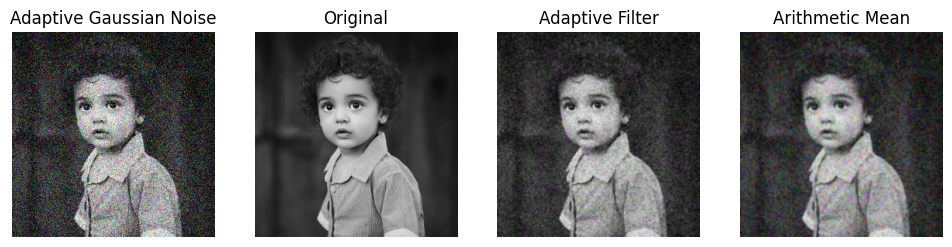

In [61]:
noisy_image = adaptive_gaussian_noise(img)
noise_var = 40 * 40
recon = adaptive_filter(noisy_image, 3, noise_var)
recon_cv = cv2.blur(noisy_image, (3, 3))

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 5))
axes[0].imshow(noisy_image)
axes[0].set_title("Adaptive Gaussian Noise")
axes[0].axis("off")
axes[1].imshow(img)
axes[1].set_title("Original")
axes[1].axis("off")
axes[2].imshow(recon)
axes[2].set_title("Adaptive Filter")
axes[2].axis("off")
axes[3].imshow(recon_cv)
axes[3].set_title("Arithmetic Mean")
axes[3].axis("off")
plt.show()

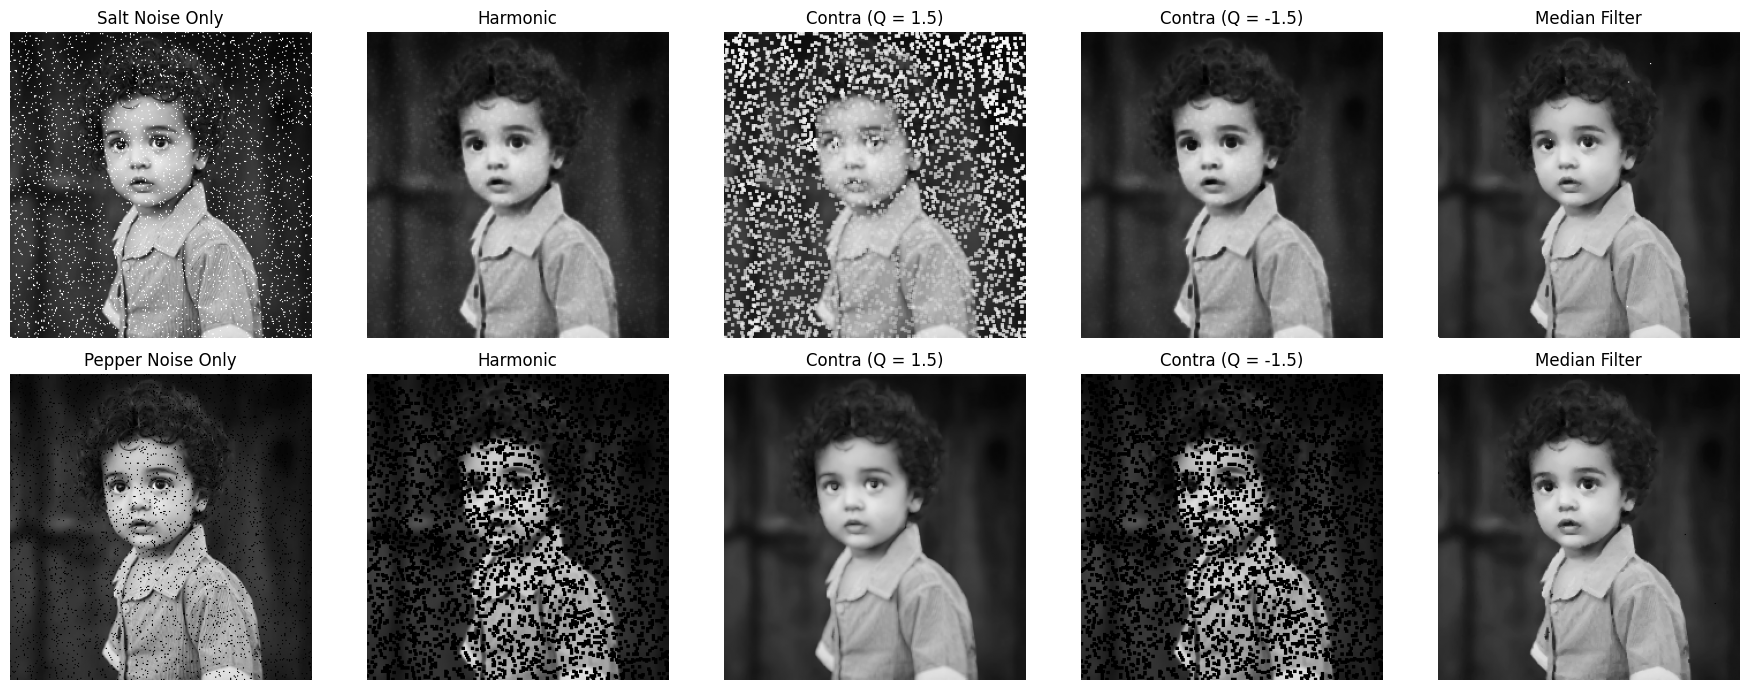

In [63]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def add_salt_pepper_noise(image, prob=0.05, salt=True, pepper=True):
    noisy = image.copy()
    if salt:
        salt_mask = np.random.rand(*image.shape) < (prob/2)
        noisy[salt_mask] = 255
    if pepper: 
        pepper_mask = np.random.rand(*image.shape) < (prob/2)
        noisy[pepper_mask] = 0
    return noisy

def harmonic_mean_filter(img, k=3):
    img_float = img.astype(np.float32) + 1e-6
    inverse_avg = cv2.blur(1.0 / img_float, (k, k))
    out = 1.0 / inverse_avg
    return np.clip(out, 0, 255).astype(np.uint8)

def contraharmonic_mean_filter(img, k=3, Q=1.5):
    img_float = img.astype(np.float32) + 1e-6 
    numerator = cv2.blur(img_float**(Q + 1), (k, k))
    denominator = cv2.blur(img_float**Q, (k, k))
    out = numerator / (denominator + 1e-6)
    return np.clip(out, 0, 255).astype(np.uint8)

img = img.astype(np.float32)

if len(img.shape) > 2:
    if img.shape[2] == 4:
        img = img[:, :, :3]
    img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) 

img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

salt_img = add_salt_pepper_noise(img, prob=0.1, salt=True, pepper=False)
pepper_img = add_salt_pepper_noise(img, prob=0.1, salt=False, pepper=True)

salt_harmonic = harmonic_mean_filter(salt_img, k=3)
salt_contra_pos = contraharmonic_mean_filter(salt_img, k=3, Q=1.5)
salt_contra_neg = contraharmonic_mean_filter(salt_img, k=3, Q=-1.5)
salt_median = cv2.medianBlur(salt_img, 3) # The ultimate fix

pepper_harmonic = harmonic_mean_filter(pepper_img, k=3)
pepper_contra_pos = contraharmonic_mean_filter(pepper_img, k=3, Q=1.5)
pepper_contra_neg = contraharmonic_mean_filter(pepper_img, k=3, Q=-1.5)
pepper_median = cv2.medianBlur(pepper_img, 3) # The ultimate fix

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(18, 7))

def format_ax(ax, image, title):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

format_ax(axes[0, 0], salt_img, "Salt Noise Only")
format_ax(axes[0, 1], salt_harmonic, "Harmonic")
format_ax(axes[0, 2], salt_contra_pos, "Contra (Q = 1.5)")
format_ax(axes[0, 3], salt_contra_neg, "Contra (Q = -1.5)")
format_ax(axes[0, 4], salt_median, "Median Filter")

format_ax(axes[1, 0], pepper_img, "Pepper Noise Only")
format_ax(axes[1, 1], pepper_harmonic, "Harmonic")
format_ax(axes[1, 2], pepper_contra_pos, "Contra (Q = 1.5)")
format_ax(axes[1, 3], pepper_contra_neg, "Contra (Q = -1.5)")
format_ax(axes[1, 4], pepper_median, "Median Filter")

plt.tight_layout()
plt.show()

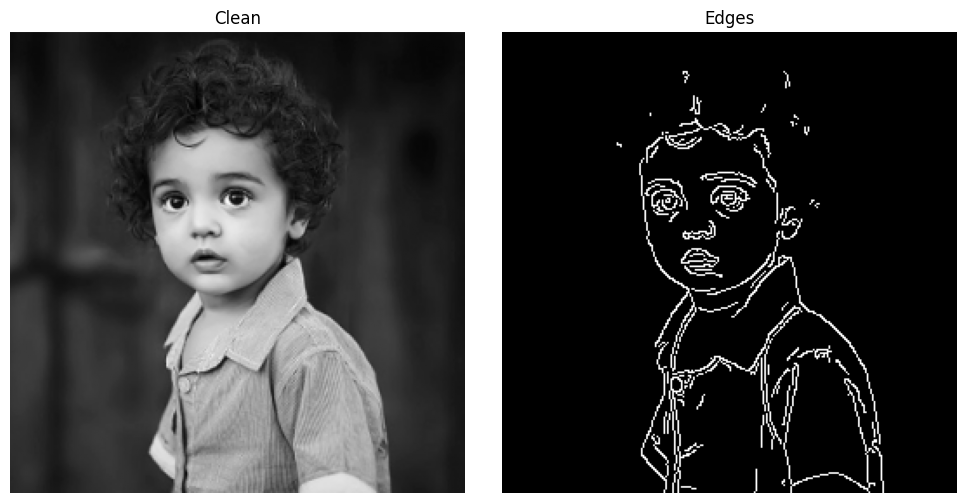

In [66]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def get_canny_edges(image, threshold1=100, threshold2=200):
    if image.dtype != np.uint8:
        if image.max() <= 1.0:
            image = (image * 255.0).astype(np.uint8)
        else:
            image = image.astype(np.uint8)

    edges = cv2.Canny(image, threshold1, threshold2)
    return edges

edge = get_canny_edges(img)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Clean")
axes[0].axis("off")

axes[1].imshow(edge, cmap='gray')
axes[1].set_title("Edges")
axes[1].axis("off")
plt.tight_layout()
plt.show()

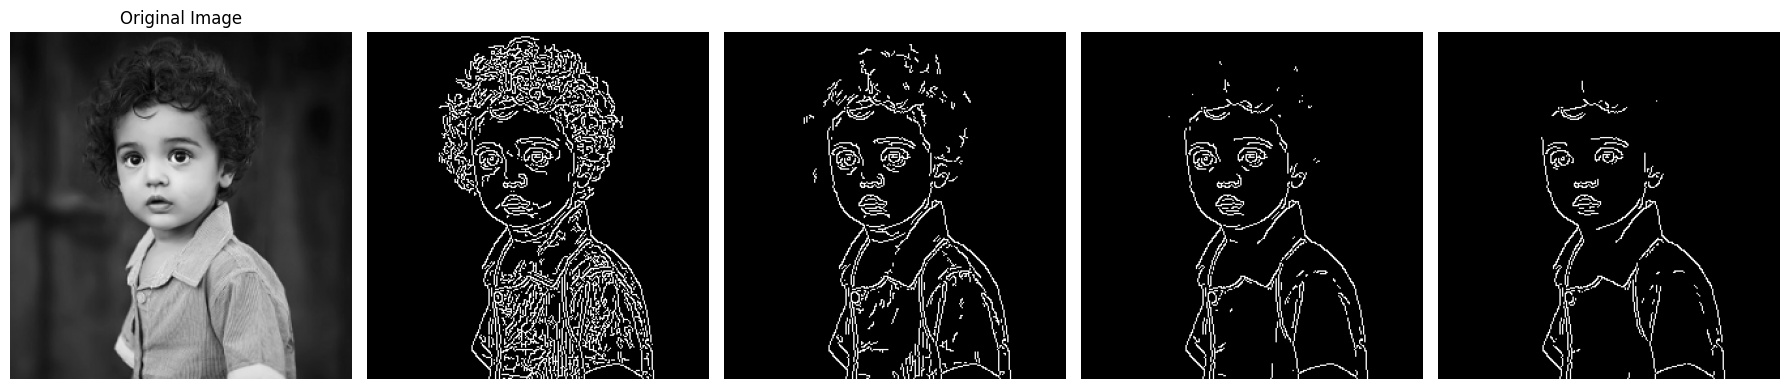

In [68]:

img_np = img
threshold_pairs = [
    (30, 80),
    (80, 150),
    (150, 200),
    (200, 250)
]

fig, axes = plt.subplots(nrows=1, ncols=len(threshold_pairs) + 1, figsize=(18, 5))
axes[0].imshow(img_np, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis("off")
for i, (t1, t2) in enumerate(threshold_pairs):
    edge_img = get_canny_edges(img_np, t1, t2)
    ax = axes[i + 1] 
    ax.imshow(edge_img, cmap='gray')
    ax.axis("off")

plt.tight_layout()
plt.show()